<h2>Covid-19 in Norway</h2>

<div style="display: flex; align-items: flex-start; gap: 10px;">

  <!-- Column 1: Emblem (smaller, fixed width) -->
  <div style="width: 120px;">
    <img src="Folkehelseinstituttet.jpg" alt="Folkehelseinstituttet emblem" width="100"/>
  </div>

  <!-- Column 2: Text (fills the rest) -->
  <div style="flex: 1;">
    <p>
      <strong>Norwegian Institute of Public Health (Folkehelseinstituttet)</strong> has published Norwegian surveillance data in a format that is easily accessible from a machine-reading perspective.
    </p>
    <p>
      🔗 <a href="https://github.com/folkehelseinstituttet/surveillance_data" target="_blank">Surveillance Data Repository</a>
      ⚠️ The repository is now archived (set to read-only)!
    </p>
  </div>

</div>






We start by load and installing necessery python packages.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint # for ODE solving

try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns

## MSIS
we start by exploring MSIS dataset. These files contain the total number of reported COVID-19 cases for Norway, the counties of Norway, and the municipalities of Norway.


In [2]:

doc_url = "https://raw.githubusercontent.com/folkehelseinstituttet/surveillance_data/master/covid19/_DOCUMENTATION_data_covid19_msis_by_time_sex_age.txt"
url_msis_sexage="https://github.com/folkehelseinstituttet/surveillance_data/raw/master/covid19/data_covid19_msis_by_time_sex_age_latest.csv"

# Get the documentation 
response = requests.get(doc_url)
documentation_text = response.text

# Print or display the content
print(documentation_text)


# Read the CSV file into a DataFrame
msis_sexage = pd.read_csv(url_msis_sexage)
msis_sexage['date']=pd.to_datetime(msis_sexage.date) # convert date to datetime




This documentation was last updated on 2021-02-05.

This is the documentation for the files:
- data_covid19_msis_by_time_sex_age_YYYY-MM-DD.xlsx
- data_covid19_msis_by_time_sex_age_YYYY-MM-DD.csv

- data_covid19_msis_by_time_sex_age_latest.csv
These files contain weekly COVID-19 epicurves for Norway by age and sex

If something does not appear to be correct, or more documentation is needed in a particular area, or you have suggestions about the way the data is presented/formatted, please email RichardAubrey.White@fhi.no

These files are generated automatically each day through an extraction from MSIS.

The variables available are listed below:
granularity_time: Temporal granularity (week)
granularity_geo: Geographical granularity (nation)
location_code: The geographical location
border: The borders (kommunesammenslåing) that location_code represents
age: Age in years
sex: Sex
year: Isoyear (prøvetakingsdato)
week: Isoweek (prøvetakingsdato)
yrwk: YYYY-WW (prøvetakingsdato)
season: Seas

In [3]:
msis_sexage


,granularity_time,granularity_geo,location_code,border,age,sex,year,week,yrwk,season,x,date,n,date_of_publishing
0,week,nation,norge,2020,0-9,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
1,week,nation,norge,2020,0-9,male,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
2,week,nation,norge,2020,10-19,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
3,week,nation,norge,2020,10-19,male,2020,8,2020-08,2019/2020,31.0,2020-02-23,0,2022-11-14
4,week,nation,norge,2020,20-29,female,2020,8,2020-08,2019/2020,31.0,2020-02-23,1,2022-11-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2855,week,nation,norge,2020,70-79,male,2022,45,2022-45,2022/2023,16.0,2022-11-13,78,2022-11-14
2856,week,nation,norge,2020,80-89,female,2022,45,2022-45,2022/2023,16.0,2022-11-13,71,2022-11-14
2857,week,nation,norge,2020,80-89,male,2022,45,2022-45,2022/2023,16.0,2022-11-13,65,2022-11-14
2858,week,nation,norge,2020,90+,female,2022,45,2022-45,2022/2023,16.0,2022-11-13,45,2022-11-14


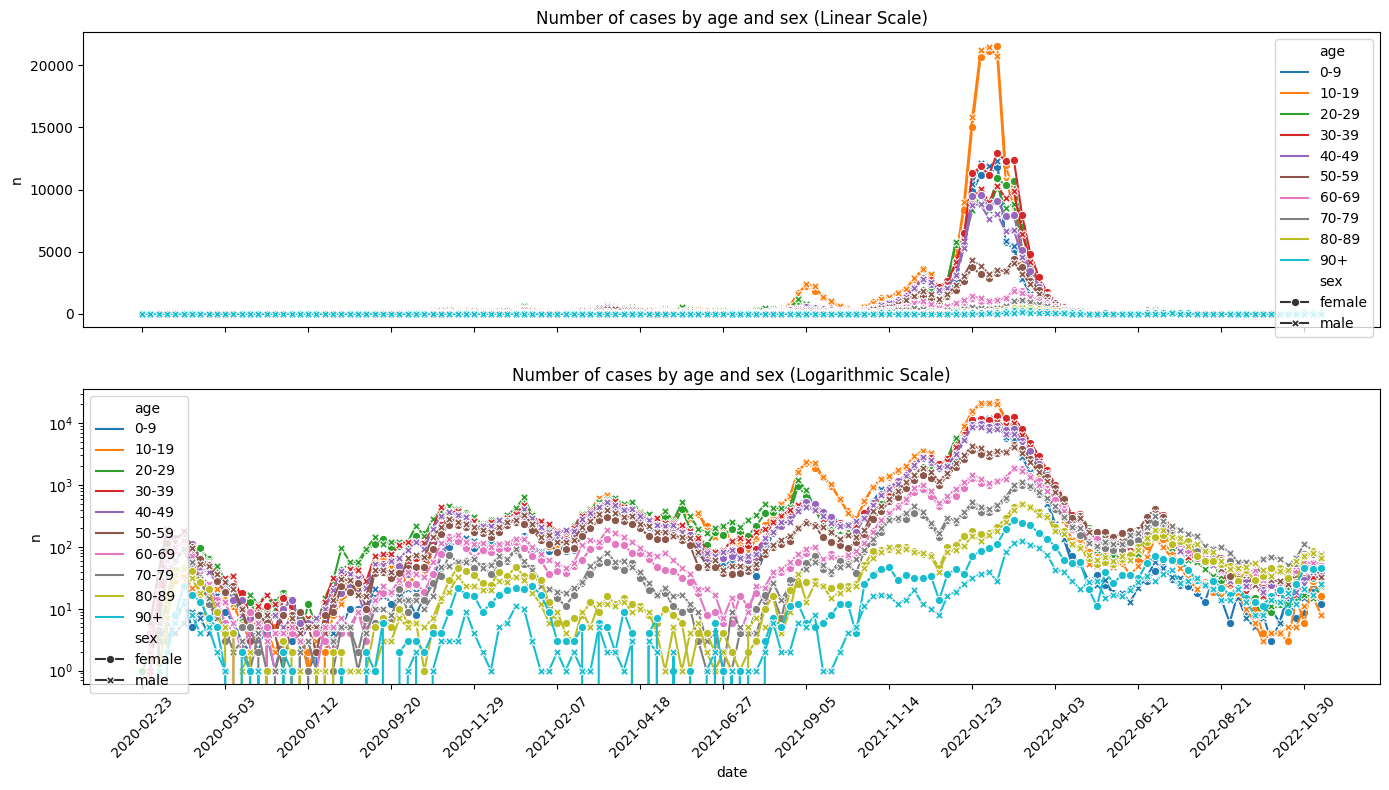

In [4]:

# Create the subplots with shared x-axis
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# First subplot: Linear scale
sns.lineplot(
    data=msis_sexage,
    x='date',
    y='n',
    hue='age',
    style='sex',
    markers=True,
    dashes=False,
    ax=ax[0]
)



ax[0].set_title('Number of cases by age and sex (Linear Scale)')

# Second subplot: Logarithmic scale
sns.lineplot(
    data=msis_sexage,
    x='date',
    y='n',
    hue='age',
    style='sex',
    markers=True,
    dashes=False,
    ax=ax[1]
)
ax[1].set_yscale('log')  # Set y-axis to log scale
ax[1].set_title('Number of cases by age and sex (Logarithmic Scale)')

# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Reduce the number of x-axis ticks by showing every Nth tick
N = 10  # Adjust N as needed
xticks = msis_sexage['date'].unique()[::N]
ax[1].set_xticks(xticks)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()




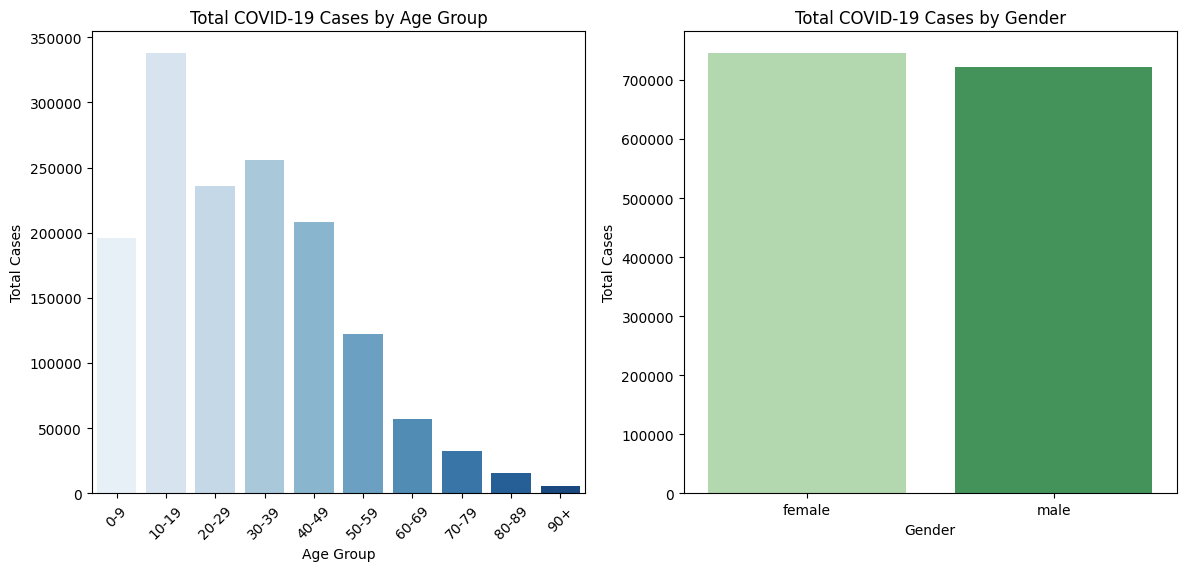

In [55]:
#Aggregate total cases by age group
age_totals = msis_sexage.groupby('age', as_index=False)['n'].sum()

# Aggregate total cases by gender
sex_totals = msis_sexage.groupby('sex', as_index=False)['n'].sum()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot for age groups
sns.barplot(data=age_totals, x='age', y='n', ax=axes[0], hue='age', palette='Blues')
axes[0].set_title('Total COVID-19 Cases by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Cases')
axes[0].tick_params(axis='x', rotation=45)

# Bar plot for gender
sns.barplot(data=sex_totals, x='sex', y='n', ax=axes[1], hue='sex', palette='Greens')
axes[1].set_title('Total COVID-19 Cases by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Total Cases')
axes[1].tick_params(axis='x', rotation=0)

In [91]:

# Group by date and sum the cases
weekly_cases = msis_sexage.groupby('date', as_index=False)['n'].sum().set_index('date')
weekly_cases.head()

,n
date,
2020-02-23,1
2020-03-01,30
2020-03-08,217
2020-03-15,1215
2020-03-22,1438


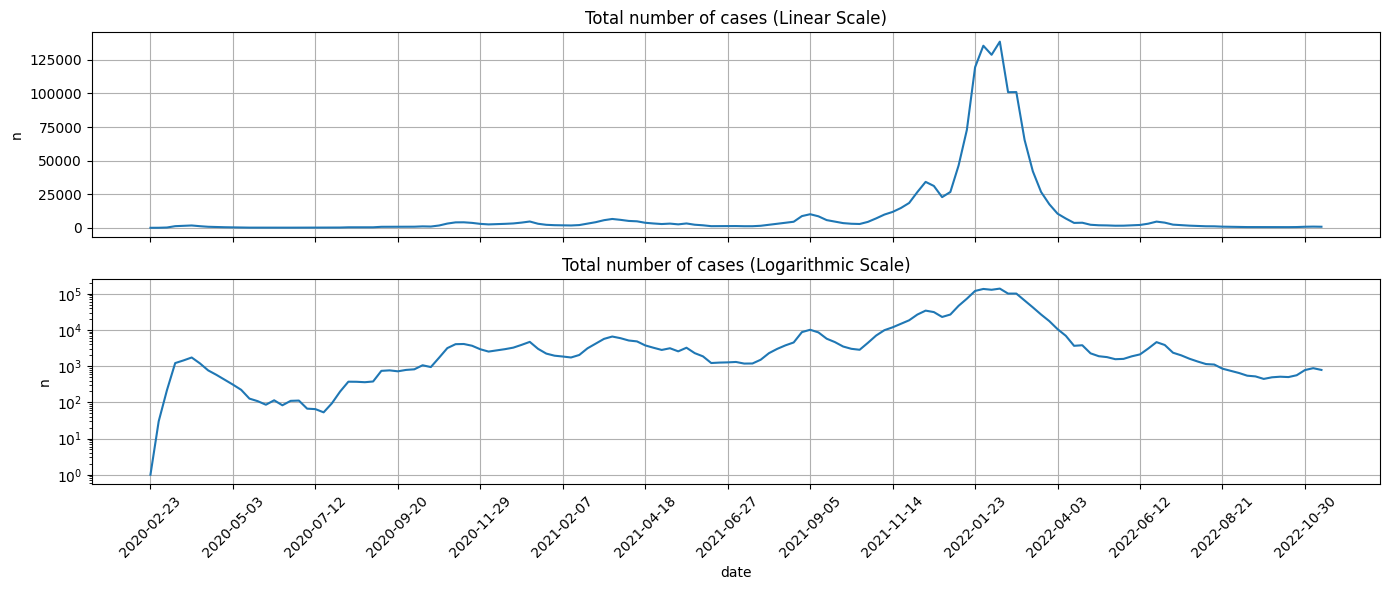

In [92]:
# Create the subplots with shared x-axis
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

sns.lineplot(
    data=weekly_cases,
    x=weekly_cases.index,
    y='n',
    ax=ax[0]
)

ax[0].set_title('Total number of cases (Linear Scale)')
ax[0].grid(True)  # Add grid to the first subplot

# Second subplot: Logarithmic scale
sns.lineplot(
    data=weekly_cases,
    x=weekly_cases.index,
    y='n',
    ax=ax[1]
)
ax[1].set_yscale('log')  # Set y-axis to log scale
ax[1].set_title('Total number of cases (Logarithmic Scale)')

# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Reduce the number of x-axis ticks by showing every Nth tick
N = 10  # Adjust N as needed
xticks = weekly_cases.index[::N]
ax[1].set_xticks(xticks)
ax[1].grid(True)  # Add grid to the first subplot

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()


In [93]:
daily_cases = weekly_cases.resample('D').interpolate(method='linear')
daily_cases

,n
date,
2020-02-23,1.000000
2020-02-24,5.142857
2020-02-25,9.285714
2020-02-26,13.428571
2020-02-27,17.571429
...,...
2022-11-09,839.142857
2022-11-10,825.857143
2022-11-11,812.571429


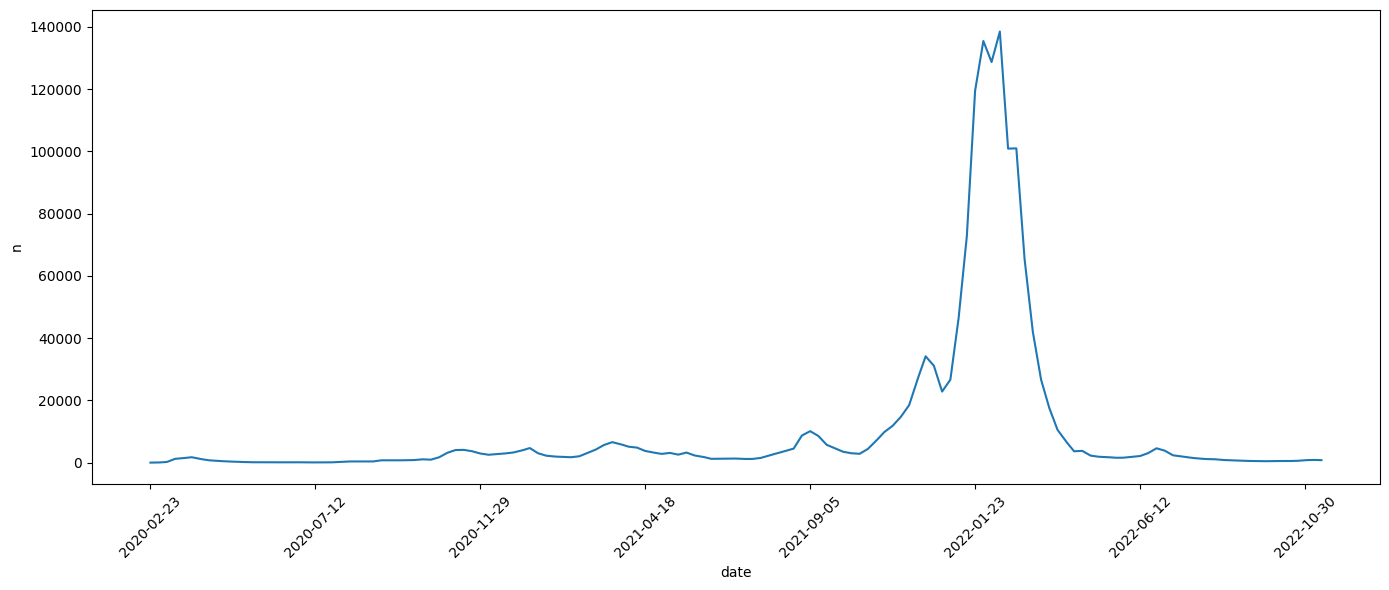

In [96]:
# Create the subplots with shared x-axis
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=daily_cases,
    x=daily_cases.index,
    y='n',
    ax=ax
)


# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Reduce the number of x-axis ticks by showing every Nth tick
N = 140  # Adjust N as needed
xticks = daily_cases.index[::N]
ax.set_xticks(xticks)


# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Daily number of tested (positive and negative) for COVID-19 in Norway

In [7]:
doc_url = "https://raw.githubusercontent.com/folkehelseinstituttet/surveillance_data/master/covid19/_DOCUMENTATION_data_covid19_lab_by_time.txt"
url_lab="https://github.com/folkehelseinstituttet/surveillance_data/raw/master/covid19/data_covid19_lab_by_time_latest.csv"

# Get the documentation 
response = requests.get(doc_url)
documentation_text = response.text

# Print or display the content
print(documentation_text)

# Read the CSV file into a DataFrame
lab = pd.read_csv(url_lab)
lab['date']=pd.to_datetime(lab.date)


This documentation was last updated on 2021-04-19.

This is the documentation for the files:
- data_covid19_lab_by_time_YYYY-MM-DD.xlsx
- data_covid19_lab_by_time_YYYY-MM-DD.csv
- data_covid19_lab_by_time_latest.csv

These files contain daily numbers of people tested for COVID-19 in Norway

If something does not appear to be correct, or more documentation is needed in a particular area, or you have suggestions about the way the data is presented/formatted, please email RichardAubrey.White@fhi.no

These files are generated automatically each day through an extraction from databases.

The variables available are listed below:
granularity_time: Temporal granularity (day)
granularity_geo: Geographical granularity (nation)
location_code: The geographical location
border: The borders (kommunesammenslåing) that location_code represents
age: Age in years
sex: Sex
year: Isoyear
week: Isoweek
yrwk: YYYY-WW
season: Seasons run week 30 -> week 29
x: Week within season
date: Date
n_neg: Number of p

In [8]:
lab.tail()

,granularity_time,granularity_geo,location_code,border,age,sex,year,week,yrwk,season,x,date,n_neg,n_pos,pr100_pos,date_of_publishing
952,day,nation,norge,2020,total,total,2022,45,2022-45,2022/2023,16.0,2022-11-09,978,150,13.3,2022-11-14
953,day,nation,norge,2020,total,total,2022,45,2022-45,2022/2023,16.0,2022-11-10,859,118,12.1,2022-11-14
954,day,nation,norge,2020,total,total,2022,45,2022-45,2022/2023,16.0,2022-11-11,589,96,14.0,2022-11-14
955,day,nation,norge,2020,total,total,2022,45,2022-45,2022/2023,16.0,2022-11-12,251,39,13.4,2022-11-14
956,day,nation,norge,2020,total,total,2022,45,2022-45,2022/2023,16.0,2022-11-13,236,36,13.2,2022-11-14


In [9]:
lab['pr100_neg'] = 100 - lab['pr100_pos']
lab.head()

,granularity_time,granularity_geo,location_code,border,age,sex,year,week,yrwk,season,x,date,n_neg,n_pos,pr100_pos,date_of_publishing,pr100_neg
0,day,nation,norge,2020,total,total,2020,14,2020-14,2019/2020,37.0,2020-04-01,3736,198,5.0,2022-11-14,95.0
1,day,nation,norge,2020,total,total,2020,14,2020-14,2019/2020,37.0,2020-04-02,3361,198,5.6,2022-11-14,94.4
2,day,nation,norge,2020,total,total,2020,14,2020-14,2019/2020,37.0,2020-04-03,3394,164,4.6,2022-11-14,95.4
3,day,nation,norge,2020,total,total,2020,14,2020-14,2019/2020,37.0,2020-04-04,1301,88,6.3,2022-11-14,93.7
4,day,nation,norge,2020,total,total,2020,14,2020-14,2019/2020,37.0,2020-04-05,1048,72,6.4,2022-11-14,93.6


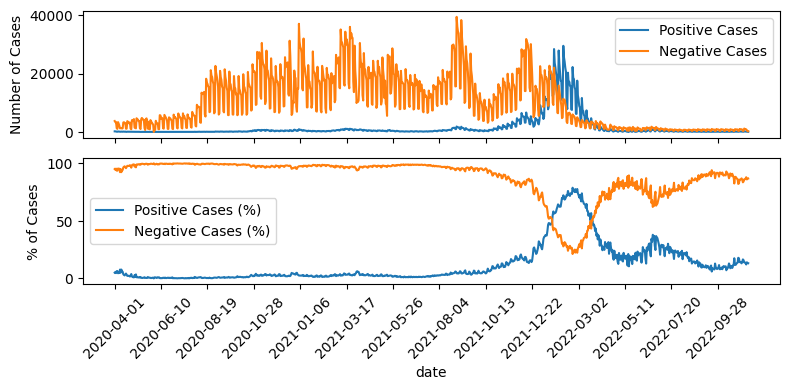

In [10]:
fig,axs=plt.subplots(2,1,figsize=(8,4), sharex=True)

#Plot the number of positive and negative cases
sns.lineplot(
    data=lab,
    x='date',
    y='n_pos',
    ax=axs[0],label='Positive Cases' )

sns.lineplot(
    data=lab,
    x='date',
    y='n_neg',
    ax=axs[0], label='Negative Cases'
)
axs[0].set_ylabel('Number of Cases')



#Plot the percentage of positive and negative cases
sns.lineplot(
    data=lab,
    x='date',
    y='pr100_pos',
    ax=axs[1],label='Positive Cases (%)'
) 

sns.lineplot(
    data=lab,
    x='date',
    y='pr100_neg',
    ax=axs[1],label='Negative Cases (%)'
) 

axs[1].set_ylabel('% of Cases')


# Reduce the number of x-axis ticks by showing every Nth tick
N = 70  # Adjust N as needed
xticks = lab['date'].unique()[::N]
axs[1].set_xticks(xticks)

# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()



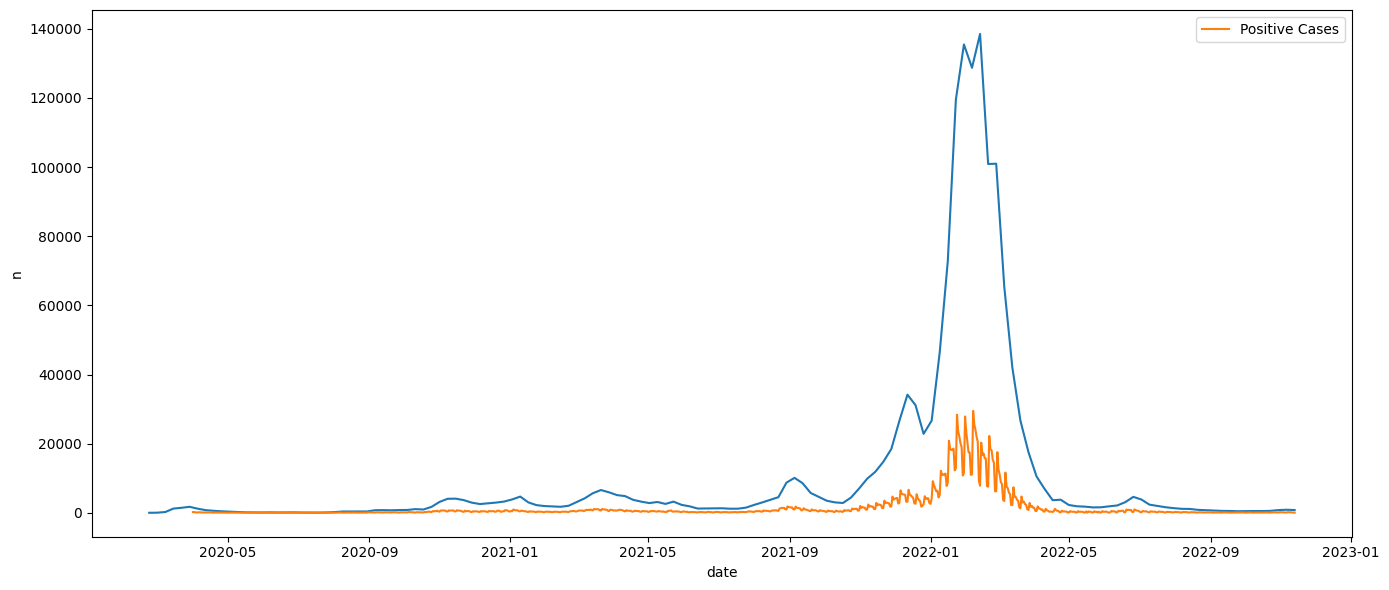

In [42]:
# Create the subplots with shared x-axis
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=msis_sexage.groupby('date', as_index=False)['n'].sum(),
    x='date',
    y='n',
    ax=ax
)
sns.lineplot(
    data=lab,
    x='date',
    y='n_pos',
    ax=ax,label='Positive Cases' )

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

In [11]:

lab2=lab[['date','n_neg','n_pos']].set_index('date')

lab2.head()

,n_neg,n_pos
date,,
2020-04-01,3736,198
2020-04-02,3361,198
2020-04-03,3394,164
2020-04-04,1301,88
2020-04-05,1048,72


## Estimate the R number

In [60]:
try:
    import epyestim 
    import pymc
except:
    !pip install epyestim
    import epyestim 
    !pip install pymc
    import pymc

from epyestim import estimate_r
import epyestim.covid19 as covid19



In [261]:

incidence_data = daily_cases['n'].rolling(window=21).mean().fillna(0)
incidence_data.tail()

date
2022-11-09    733.673469
2022-11-10    747.551020
2022-11-11    760.374150
2022-11-12    772.142857
2022-11-13    782.857143
Freq: D, Name: n, dtype: float64

In [262]:
r_estimates = covid19.r_covid(incidence_data)#, smoothing_window=7)

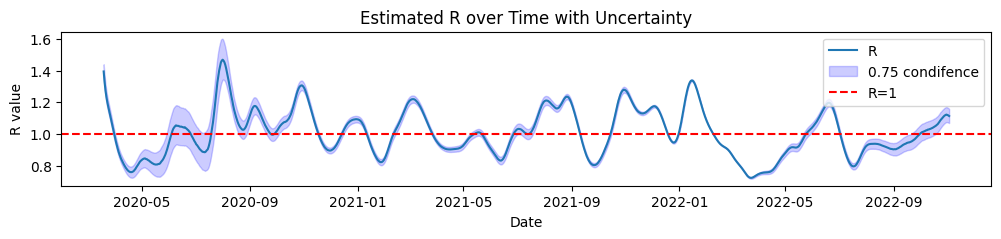

In [263]:
##OLD BUT GOLD!
# Generate synthetic data for the number of new infections per day

#incidence_data = lab2['n_pos'].rolling(window=7).mean().fillna(0)
#incidence_data = daily_cases['n'].rolling(window=3).mean().bfill()

# Estimate the R number using epyestim
r_estimates = covid19.r_covid(incidence_data)#, smoothing_window=7)
r_estimates.index = pd.to_datetime(r_estimates.index) 
r_estimates['R_std']=np.sqrt(r_estimates['R_var'])


# Plot the R estimates with uncertainty
fig, ax = plt.subplots(figsize=(12, 2))
sns.lineplot(data=r_estimates, x=r_estimates.index, y='R_mean', ax=ax, label='R')
ax.fill_between(r_estimates.index, r_estimates['Q0.025'], r_estimates['Q0.975'], color='b', alpha=0.2, label='0.75 condifence')
ax.axhline(y=1, color='r', linestyle='--', label='R=1')
ax.set_xlabel('Date')
ax.set_ylabel('R value')
ax.set_title('Estimated R over Time with Uncertainty')
# Plot the incident data on the twin axis
ax.legend()

plt.show()

In [264]:
r_estimates.head()

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975,R_std
2020-03-19,558.0,1.394699,0.000525,1.350289,1.394574,1.439887,0.022908
2020-03-20,622.0,1.329702,0.000452,1.288182,1.329588,1.371811,0.021264
2020-03-21,688.0,1.277614,0.000398,1.238968,1.277511,1.316952,0.019962
2020-03-22,755.0,1.237395,0.000359,1.200632,1.237299,1.274778,0.018945
2020-03-23,823.0,1.205079,0.000328,1.170000,1.204989,1.240663,0.018106


Text(0.5, 0, 'Days since')

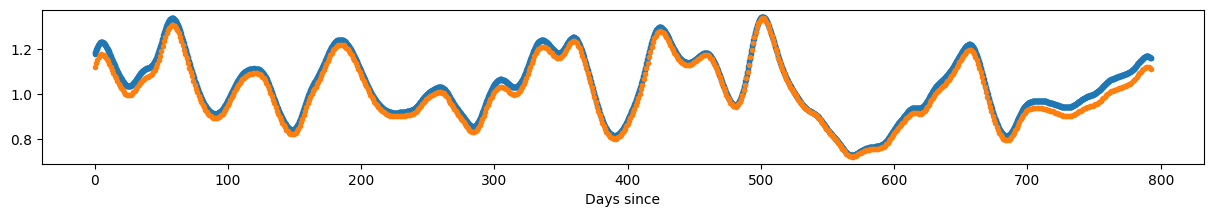

In [270]:
def R_interp(t, r_estimates, str):
    """
    Interpolates the R values for the given time points.
    str ='R_mean' or 'Q0.975' or 'Q0.025'
    t: Time points for interpolation
    """

    days =(r_estimates.index - r_estimates.index[0]).days
    # Interpolate R values using linear interpolation
    #R_values = np.interp(t, days, r_estimates['R_mean'])
    R_values = np.interp(t, days, r_estimates[str])
    
    return R_values

# Example usage
day0 = pd.to_datetime('2020-09-01')  # Adjust as needed
days_since = (r_estimates.index - day0).days

# Create a range of days from day0 to the maximum number of days
total_days = days_since.max()
days_range = np.linspace(0, total_days, total_days+1)

t = np.arange(0, total_days, 0.25)      # Time points for interpolation    
r_estimates_filtered = r_estimates.loc[r_estimates.index >= day0]
R_values = R_interp(t,r_estimates_filtered,'Q0.975')


fig, ax = plt.subplots(figsize=(15, 2))
ax.plot(t, R_values,'.')
ax.plot(days_range, r_estimates_filtered['R_mean'],'.')
plt.xlabel('Days since') 

# SIRS model

In [204]:

def deriv(X, t, N, gamma, eta, r_estimates, key ='R_mean'):
    S, I, R = X
    beta =  R_interp(t,r_estimates,key)*gamma
    dSdt = -beta * S * I / N + eta*R
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I - eta*R
    return dSdt, dIdt, dRdt

## SIRS starting with a selected day as $\rm day_0$

In [275]:
# Recovery rate γ (assumed constant)
gamma = 1/7  # Recovery rate (e.g., 7 days infectious period)
eta = 1/30 # Rate of re-infection (e.g., 30 days after recovering)

# Total population, N
N = 5400000  # Total population (e.g., 5.4 million)


# Define the start date and end date for the simulation
day0 = r_estimates.index[0] 
#day0 =pd.to_datetime('2020-09-11')  
dayN = r_estimates.index[-1]


r_estimates_filtered = r_estimates.loc[day0:dayN]

daily_cases_filtered = daily_cases.loc[day0:dayN]



total_days = (dayN - day0).days

t = np.linspace(0, total_days, total_days+1)


# Initial number of infected and recovered individuals
#I0 =r_estimates_filtered.loc[day0]['cases'] # Number of infected individuals at day0
#print(I0)

I0 =daily_cases.loc[day0]['n'] # Number of infected individuals at day0
print(I0)

R0 = 0
S0 = N - I0 - R0

# Initial conditions vector
X0 = S0, I0, R0





1342.4285714285713


In [276]:
r_estimates_filtered.iloc[0]

cases     558.000000
R_mean      1.394699
R_var       0.000525
Q0.025      1.350289
Q0.5        1.394574
Q0.975      1.439887
R_std       0.022908
Name: 2020-03-19 00:00:00, dtype: float64

In [277]:
# Integrate the SIR equatio r_estimates.columns:ns over the time grid, t
SIR_dict = {}




for key in ['R_mean', 'Q0.025', 'Q0.975']:
    ret = odeint(deriv, X0, t, args=(N, gamma, eta, r_estimates_filtered, key))
    SIR_dict['S for ' + key] = ret.T[0]
    SIR_dict['I for ' + key] = ret.T[1]
    SIR_dict['R for ' + key] = ret.T[2]

SIR = pd.DataFrame(SIR_dict, index=t)
SIR

,S for R_mean,I for R_mean,R for R_mean,S for Q0.025,I for Q0.025,R for Q0.025,S for Q0.975,I for Q0.975,R for Q0.975
0.0,5.398658e+06,1342.428571,0.000000,5.398658e+06,1342.428571,0.000000,5.398658e+06,1342.428571,0.000000
1.0,5.398393e+06,1413.643273,193.752047,5.398402e+06,1404.995543,193.143776,5.398383e+06,1422.482684,194.372897
2.0,5.398133e+06,1476.227890,390.535769,5.398153e+06,1458.823262,388.113833,5.398113e+06,1494.122028,393.016327
3.0,5.397879e+06,1531.442580,589.124092,5.397911e+06,1505.261526,583.716735,5.397847e+06,1558.518883,594.684570
4.0,5.397631e+06,1580.502632,788.513492,5.397675e+06,1545.536615,778.984037,5.397585e+06,1616.845729,798.350113
...,...,...,...,...,...,...,...,...,...
955.0,5.390440e+06,1834.010012,7726.265901,5.399718e+06,44.127922,238.252789,5.363744e+06,8151.531735,28104.405559
956.0,5.390402e+06,1865.537307,7732.865428,5.399719e+06,44.596970,236.674868,5.363317e+06,8341.719905,28341.709113
957.0,5.390359e+06,1897.602884,7743.730497,5.399720e+06,45.075727,235.215601,5.362866e+06,8535.414153,28598.261650
958.0,5.390312e+06,1929.527881,7758.736284,5.399721e+06,45.548196,233.871032,5.362397e+06,8729.543440,28873.659475


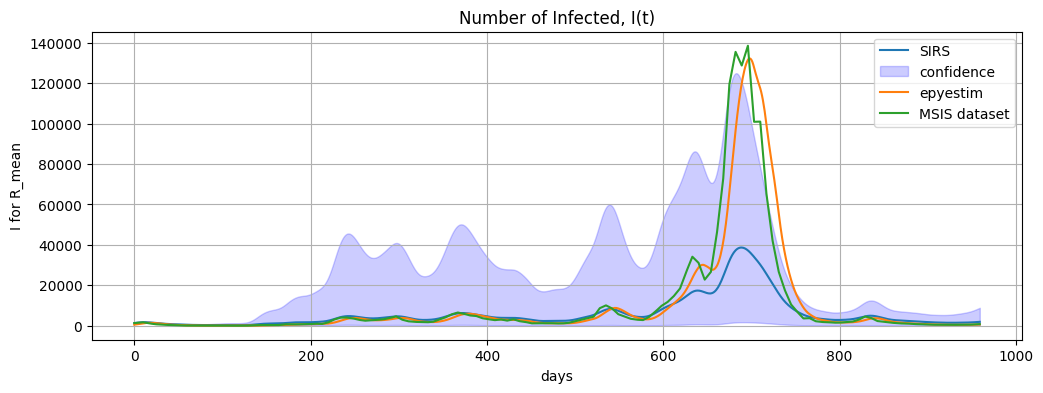

In [278]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=SIR, x=SIR.index, y='I for R_mean', ax=ax, label='SIRS')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
ax.fill_between(SIR.index, SIR['I for Q0.025'], SIR['I for Q0.975'], color='b', alpha=0.2, label='confidence')
sns.lineplot(data=r_estimates_filtered, x=SIR.index, y='cases', ax=ax, label='epyestim')

sns.lineplot(data=daily_cases_filtered, x=SIR.index, y='n', ax=ax, label='MSIS dataset')

#ax.plot(T,aggregated_df['n'], 'k', label='MSIS dataset')

ax.set_xlabel('days')
ax.set_title('Number of Infected, I(t)')
ax.legend()

plt.grid(True)
plt.show()

<Axes: xlabel='None', ylabel='R_plus_I'>

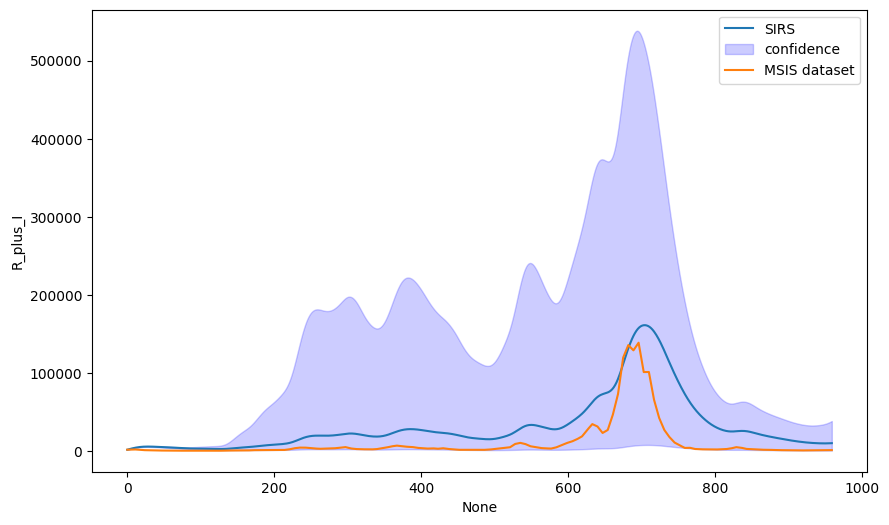

In [281]:
SIR['R_plus_I'] = SIR['R for R_mean'] + SIR['I for R_mean']
SIR['R_plus_I_Q0.025'] = SIR['R for Q0.025'] + SIR['I for Q0.025']
SIR['R_plus_I_Q0.975'] = SIR['R for Q0.975'] + SIR['I for Q0.975']

fir, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=SIR, x=SIR.index, y='R_plus_I', ax=ax, label='SIRS')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
ax.fill_between(SIR.index, SIR['R_plus_I_Q0.025'], SIR['R_plus_I_Q0.975'], color='b', alpha=0.2, label='confidence')

sns.lineplot(data=daily_cases_filtered, x=SIR.index, y='n', ax=ax, label='MSIS dataset')


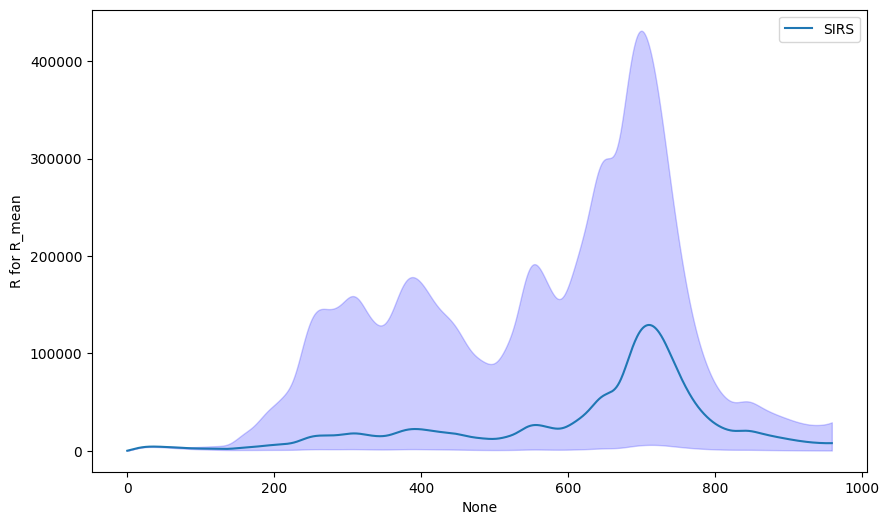

In [284]:

fir, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=SIR, x=SIR.index, y='R for R_mean', ax=ax, label='SIRS')
ax.fill_between(SIR.index, SIR['R for Q0.025'], SIR['R for Q0.975'], color='b', alpha=0.2, label='confidence')




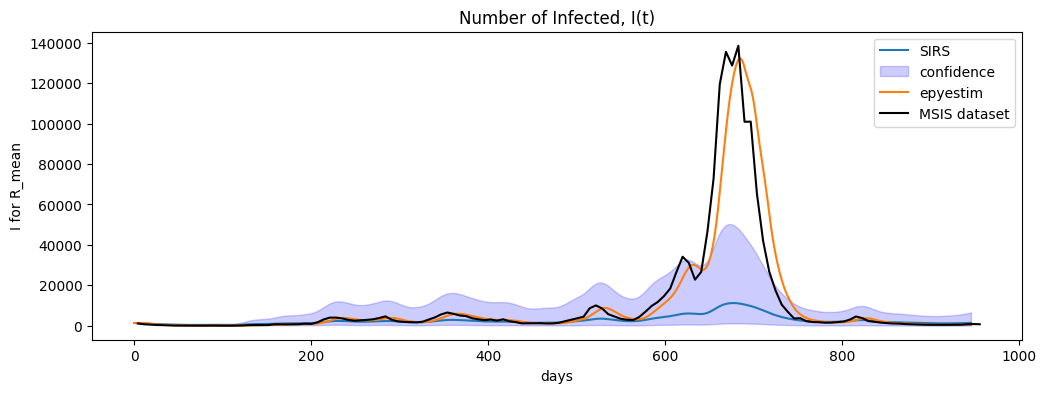

In [155]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=I, x=I.index, y='I for R_mean', ax=ax, label='SIRS')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
#sns.lineplot(data=I, x=I.index, y='I for Q0.025', ax=ax, label='I_low')
ax.fill_between(I.index, I['I for Q0.025'], I['I for Q0.975'], color='b', alpha=0.2, label='confidence')
sns.lineplot(data=r_estimates_filtered, x=I.index, y='cases', ax=ax, label='epyestim')

ax.plot(T,aggregated_df['n'], 'k', label='MSIS dataset')

ax.set_xlabel('days')
ax.set_title('Number of Infected, I(t)')
ax.legend()

plt.show()